In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from tabulate import tabulate

In [15]:
import pandas as pd

# 讀取原始資料
file = 'tej_financialdata_20140101-20241231.xlsx'
df = pd.read_excel(file)

# 轉換數值型態
value_cols = ['流動資產', '流動負債', '資產總額', '  保留盈餘', '來自營運之現金流量', '負債總額']
for col in value_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 計算財務比率
working_capital_total_assets = (df['流動資產'] - df['流動負債']) / df['資產總額']
retained_earnings_total_assets = df['  保留盈餘'] / df['資產總額']
cashflow_total_debt = df['來自營運之現金流量'] / df['負債總額']
total_debt_total_assets = df['負債總額'] / df['資產總額']
current_ratio = df['流動資產'] / df['流動負債']

# 建立新 DataFrame
ratios_df = pd.DataFrame({
    '公司': df['公司'],
    '年/月': df['年/月'],
    'WorkingCapital_TotalAssets': working_capital_total_assets,
    'RetainedEarnings_TotalAssets': retained_earnings_total_assets,
    'CashFlow_TotalDebt': cashflow_total_debt,
    'TotalDebt_TotalAssets': total_debt_total_assets,
    'CurrentRatio': current_ratio
})

# 檢查結果
print(ratios_df.head())
ratios_df.to_excel('ratios.xlsx', index=False)

        公司      年/月  WorkingCapital_TotalAssets  RetainedEarnings_TotalAssets  \
0  1101 台泥  2024/12                    0.146621                      0.122633   
1  1101 台泥  2020/06                    0.102824                      0.155888   
2  1101 台泥  2021/06                    0.161413                      0.221727   
3  1101 台泥  2018/12                    0.133330                      0.178993   
4  1101 台泥  2018/06                    0.114156                      0.155965   

   CashFlow_TotalDebt  TotalDebt_TotalAssets  CurrentRatio  
0            0.111360               0.481124      2.007338  
1            0.098034               0.489048      1.461879  
2            0.078609               0.405556      1.877726  
3            0.150987               0.426364      1.711227  
4            0.072544               0.463646      1.537869  


In [16]:
ratios=ratios_df[['WorkingCapital_TotalAssets', 'RetainedEarnings_TotalAssets', 'CashFlow_TotalDebt', 'TotalDebt_TotalAssets', 'CurrentRatio']]
def profiling():
  col = ['mean', 'std', 'min', '50%', 'max']
  summary = ratios.describe()
  na = pd.DataFrame(ratios.isnull().sum()/len(ratios)*100,columns = ['NA(%)']).T #計算缺失率
  skew = pd.DataFrame(ratios.skew(),columns=["skewness"]).T #偏度
  kurt = pd.DataFrame(ratios.kurtosis(),columns=["kurtosis"]).T #峰度
  print(tabulate(pd.concat([na, summary.loc[col], skew, kurt]), headers=ratios.columns))
profiling()

            WorkingCapital_TotalAssets    RetainedEarnings_TotalAssets    CashFlow_TotalDebt    TotalDebt_TotalAssets    CurrentRatio
--------  ----------------------------  ------------------------------  --------------------  -----------------------  --------------
NA(%)                        3.13318                          0                    0.0964763               0                3.13318
mean                         0.260084                         0.111762             0.109787                0.457993         3.04299
std                          0.205335                         1.27573              0.49632                 0.195864        11.1524
min                         -0.742243                       -82.0719             -18.1768                  0.00303337       0.0588412
50%                          0.251428                         0.150736             0.080471                0.454693         1.79589
max                          0.996967                         1.58174  

In [17]:
median=ratios_df.describe().loc['50%']
print(median)

WorkingCapital_TotalAssets      0.251428
RetainedEarnings_TotalAssets    0.150736
CashFlow_TotalDebt              0.080471
TotalDebt_TotalAssets           0.454693
CurrentRatio                    1.795890
Name: 50%, dtype: float64


In [18]:
print(ratios_df[ratios_df.isnull().any(axis=1)])


                   公司      年/月  WorkingCapital_TotalAssets  \
10067         2801 彰銀  2014/12                         NaN   
10068         2801 彰銀  2023/06                         NaN   
10069         2801 彰銀  2018/12                         NaN   
10070         2801 彰銀  2017/06                         NaN   
10071         2801 彰銀  2015/12                         NaN   
...               ...      ...                         ...   
19413       6936 永鴻生技  2018/12                    0.209544   
19425         6937 天虹  2019/12                    0.153294   
19485    7722 LINEPAY  2019/12                    0.541482   
19499       7732 金興精密  2019/12                   -0.101725   
20870  911868 同方友友-DR  2014/12                    0.461994   

       RetainedEarnings_TotalAssets  CashFlow_TotalDebt  \
10067                      0.021899            0.001652   
10068                      0.024430           -0.018913   
10069                      0.026550           -0.001795   
10070              

In [19]:
import numpy as np
import pandas as pd

# 1️⃣ 依公司代號前兩碼分群
ratios_df['stock_prefix'] = ratios_df['公司'].astype(str).str[:2]

# 2️⃣ 建立缺值指標欄位（在 groupby 之前）
cols = ['WorkingCapital_TotalAssets', 'RetainedEarnings_TotalAssets', 
        'CashFlow_TotalDebt', 'TotalDebt_TotalAssets', 'CurrentRatio']

for col in cols:
    ratios_df[f'{col}_miss'] = ratios_df[col].isna().astype(int)

# 3️⃣ 補值函式
def fill_with_group_median(group):
    for col in cols:
        group_median = group[col].median()
        if pd.isna(group_median):
            group_median = median[col]  # median 需事先定義或全體取 median
        group[col] = group[col].fillna(group_median)
    return group

# 4️⃣ 依群組補值
ratios_filled_df = ratios_df.groupby('stock_prefix', group_keys=False).apply(fill_with_group_median)

# 5️⃣ 踢除極端值與取 log（注意順序：先踢再 log）
for col in cols:
    mean = ratios_filled_df[col].mean()
    std = ratios_filled_df[col].std()
    ratios_filled_df = ratios_filled_df[
        (ratios_filled_df[col] >= mean - 3*std) & 
        (ratios_filled_df[col] <= mean + 3*std)
    ]
    ratios_filled_df[col] = np.sign(ratios_filled_df[col]) * np.log1p(np.abs(ratios_filled_df[col]))

# 6️⃣ 檢查結果
print(ratios_filled_df[['公司', '年/月'] + cols + [f'{c}_miss' for c in cols]].head())

# 7️⃣ 輸出
ratios_filled_df.to_excel('ratios_filled.xlsx', index=False)


        公司      年/月  WorkingCapital_TotalAssets  RetainedEarnings_TotalAssets  \
0  1101 台泥  2024/12                    0.136820                      0.115677   
1  1101 台泥  2020/06                    0.097874                      0.144869   
2  1101 台泥  2021/06                    0.149637                      0.200266   
3  1101 台泥  2018/12                    0.125160                      0.164661   
4  1101 台泥  2018/06                    0.108097                      0.144936   

   CashFlow_TotalDebt  TotalDebt_TotalAssets  CurrentRatio  \
0            0.105585               0.392801      1.101055   
1            0.093521               0.398137      0.900925   
2            0.075672               0.340433      1.057000   
3            0.140620               0.355129      0.997401   
4            0.070034               0.380931      0.931325   

   WorkingCapital_TotalAssets_miss  RetainedEarnings_TotalAssets_miss  \
0                                0                                 

In [20]:
ratios=ratios_filled_df[['WorkingCapital_TotalAssets', 'RetainedEarnings_TotalAssets', 'CashFlow_TotalDebt', 'TotalDebt_TotalAssets', 'CurrentRatio']]
def profiling():
  col = ['mean', 'std', 'min', '50%', 'max']
  summary = ratios.describe()
  na = pd.DataFrame(ratios.isnull().sum()/len(ratios)*100,columns = ['NA(%)']).T #計算缺失率
  skew = pd.DataFrame(ratios.skew(),columns=["skewness"]).T #偏度
  kurt = pd.DataFrame(ratios.kurtosis(),columns=["kurtosis"]).T #峰度
  print(tabulate(pd.concat([na, summary.loc[col], skew, kurt]), headers=ratios.columns))
profiling()

            WorkingCapital_TotalAssets    RetainedEarnings_TotalAssets    CashFlow_TotalDebt    TotalDebt_TotalAssets    CurrentRatio
--------  ----------------------------  ------------------------------  --------------------  -----------------------  --------------
NA(%)                        0                                0                    0                        0               0
mean                         0.215023                         0.135149             0.103381                 0.373306        1.08464
std                          0.15288                          0.167935             0.186678                 0.129052        0.380631
min                         -0.298188                        -1.53474             -0.78052                  0.0258126       0.0741276
50%                          0.215281                         0.141115             0.0783935                0.378056        1.00802
max                          0.623079                         0.948465     

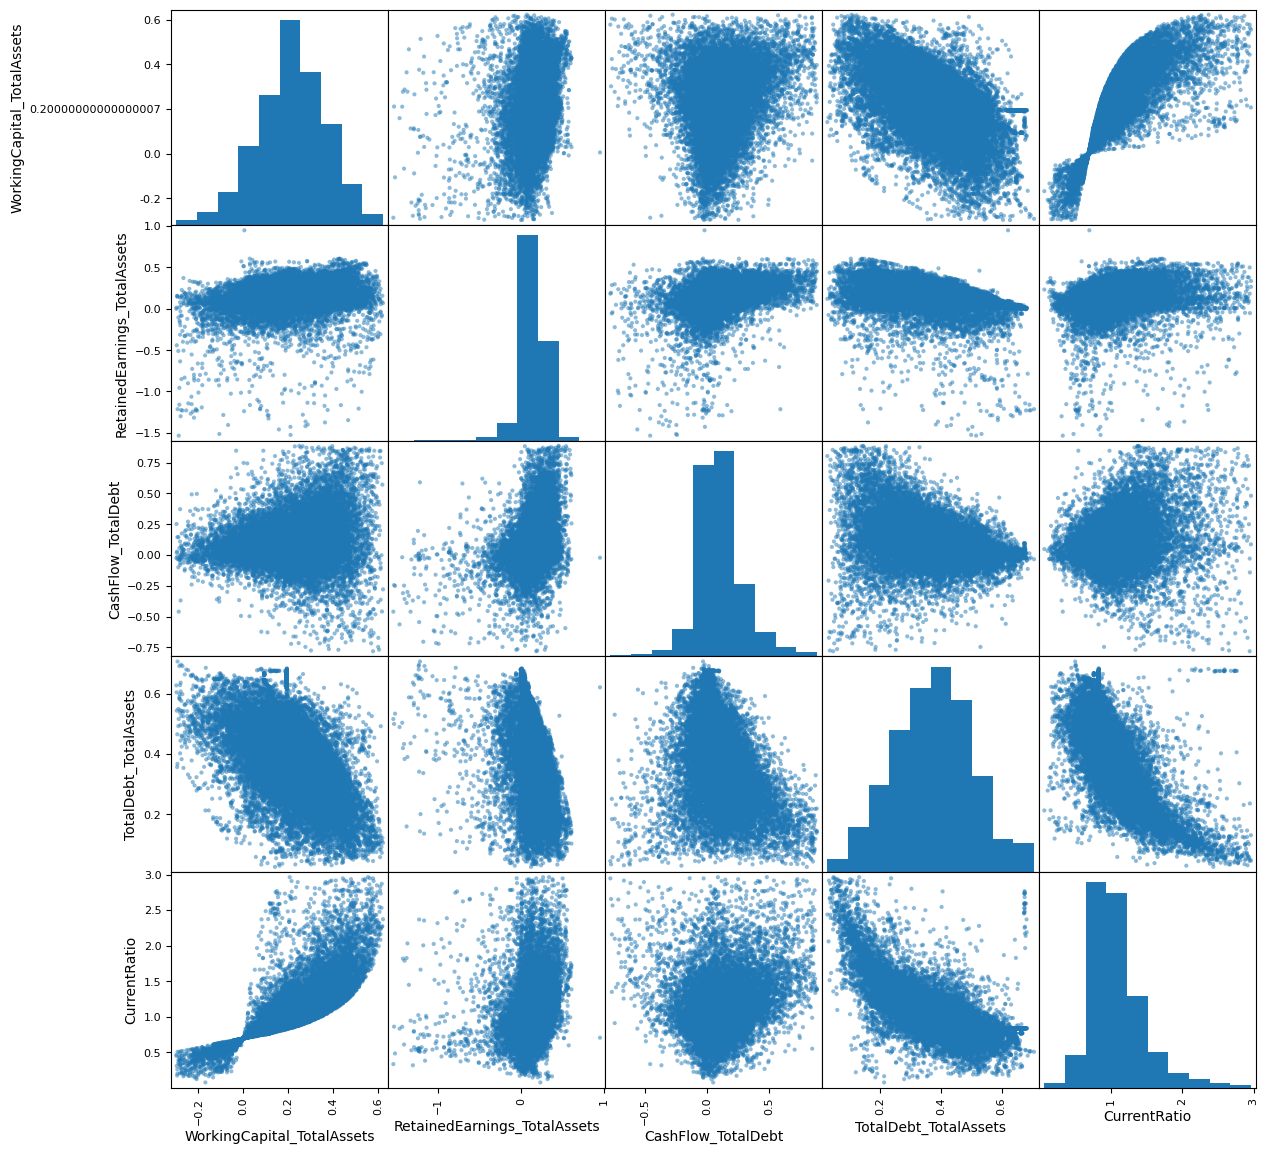

In [21]:
axes=pd.plotting.scatter_matrix(ratios_filled_df[['WorkingCapital_TotalAssets', 'RetainedEarnings_TotalAssets', 'CashFlow_TotalDebt', 
                                             'TotalDebt_TotalAssets', 'CurrentRatio']],figsize=(14, 14))
# for ax in axes.flatten():
#     ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
#     ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
plt.savefig('scatter_matrix.png', transparent=True)


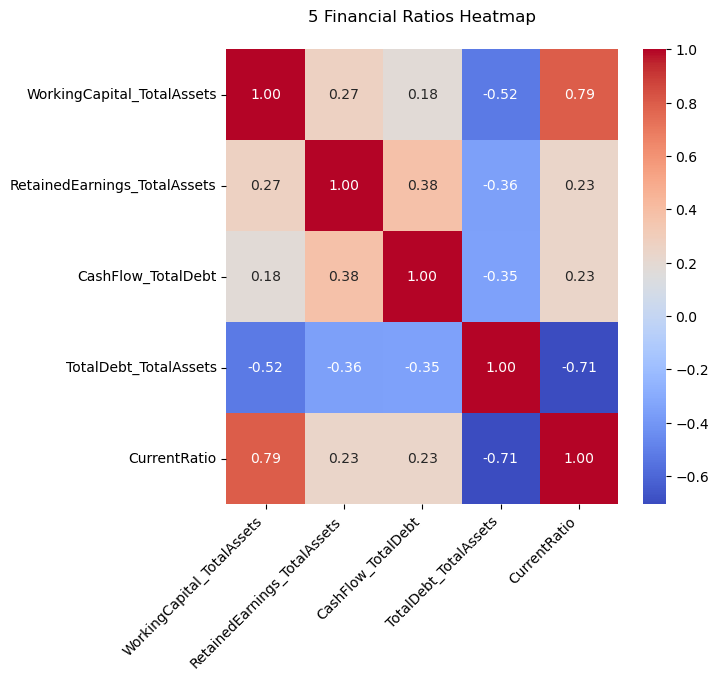

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# 選取五個財務比率
cols = ['WorkingCapital_TotalAssets', 'RetainedEarnings_TotalAssets', 'CashFlow_TotalDebt', 'TotalDebt_TotalAssets', 'CurrentRatio']

# 計算相關係數矩陣
corr = ratios_filled_df[cols].corr()

plt.figure(figsize=(7, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('5 Financial Ratios Heatmap', pad=20)  # pad 增加標題與圖的距離

# 旋轉 X 軸文字，避免重疊或被吃掉
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# 🔧 關鍵：手動調整邊界
plt.subplots_adjust(left=0.25, right=0.95, top=0.9, bottom=0.25)

plt.savefig('heatmap.png', transparent=True, bbox_inches='tight')



# 分產業

https://isin.twse.com.tw/isin/class_main.jsp?market=1&issuetype=1